# 19. yfinance 배당 데이터 직접 확인

MC 에 넣은 배당이 어디서 왔는지 눈으로 확인하는 노트북이다. **캐시를 쓰지 않고 실행할 때마다 yfinance API 를 새로 호출**한다.

- 대상: **삼성전자 (005930.KS)** — 기초자산으로 자주 쓰이는 종목 중 아무거나.
- 확인할 것: ① `Ticker.dividends` 가 배당락일 · 주당 배당금을 돌려주는가 ② `history()` 응답에 **`Dividends` 열**이 실제로 있는가
  ③ 지수 티커는 왜 0 건인가 ④ 우리가 저장해 둔 캐시가 API 값과 같은가.
- 호출 방식은 캐시를 받을 때와 같다: `history(start=..., auto_adjust=False, actions=True)` — `auto_adjust=False` 라 종가는 배당 조정 전 원본이다.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from util import file_manager as fm, plot as _plot     # import 만으로 dpi400·투명·PPT 밴드

TK = "005930.KS"      # 삼성전자
print("yfinance 버전:", yf.__version__, "| 호출 시각:", pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"))
t = yf.Ticker(TK)
div = t.dividends                      # 배당락일 index, 주당 배당금 value
print(f"{TK} 배당 {len(div)}건 | {div.index.min().date()} ~ {div.index.max().date()} | 단위: 원/주")
div.tail(10)

yfinance 버전: 1.5.1 | 호출 시각: 2026-09-16 12:24


005930.KS 배당 60건 | 2006-06-29 ~ 2026-06-29 | 단위: 원/주


Date
2024-03-28 09:00:00+09:00    361.0
2024-06-27 09:00:00+09:00    361.0
2024-09-27 09:00:00+09:00    361.0
2024-12-27 09:00:00+09:00    363.0
2025-03-28 09:00:00+09:00    365.0
2025-06-27 09:00:00+09:00    367.0
2025-09-29 09:00:00+09:00    370.0
2025-12-29 09:00:00+09:00    566.0
2026-03-30 09:00:00+09:00    372.0
2026-06-29 09:00:00+09:00    374.0
Name: Dividends, dtype: float64

## 19-1. `history()` 응답에 `Dividends` 열이 있는가

배당만 따로 받은 게 아니라, 가격 표 자체에 `Dividends` 열이 같이 온다. 아래가 API 가 돌려준 원본 표다.

In [2]:
h = t.history(start="2023-01-01", auto_adjust=False, actions=True)
print("API 가 돌려준 열:", list(h.columns))
print(f"행 {len(h):,}개 ({h.index.min().date()} ~ {h.index.max().date()})  |  Dividends > 0 인 행 {int((h['Dividends'] > 0).sum())}개")
h.tail(5)

API 가 돌려준 열: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Dividends', 'Stock Splits']
행 904개 (2023-01-02 ~ 2026-09-16)  |  Dividends > 0 인 행 14개


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2026-09-10 00:00:00+09:00,269000.0,270500.0,263500.0,269000.0,269000.0,22517075,0.0,0.0
2026-09-11 00:00:00+09:00,258000.0,261500.0,256500.0,259500.0,259500.0,13939111,0.0,0.0
2026-09-14 00:00:00+09:00,249500.0,254500.0,248500.0,249000.0,249000.0,17776098,0.0,0.0
2026-09-15 00:00:00+09:00,248000.0,252000.0,246000.0,248500.0,248500.0,11435506,0.0,0.0
2026-09-16 00:00:00+09:00,248000.0,252500.0,247500.0,252500.0,252500.0,5115652,0.0,0.0


배당락일만 뽑으면 이렇게 분기마다 찍힌다.

In [3]:
ev = h.loc[h["Dividends"] > 0, ["Close", "Dividends"]].copy()
ev["배당/종가 %"] = (ev["Dividends"] / ev["Close"] * 100).round(2)
ev

,Close,Dividends,배당/종가 %
Date,,,
2023-03-30 00:00:00+09:00,63200.0,361.0,0.57
2023-06-29 00:00:00+09:00,72400.0,361.0,0.50
2023-09-26 00:00:00+09:00,68600.0,361.0,0.53
2023-12-27 00:00:00+09:00,78000.0,361.0,0.46
2024-03-28 00:00:00+09:00,80800.0,361.0,0.45
2024-06-27 00:00:00+09:00,81600.0,361.0,0.44
2024-09-27 00:00:00+09:00,64200.0,361.0,0.56
2024-12-27 00:00:00+09:00,53700.0,363.0,0.68
2025-03-28 00:00:00+09:00,60200.0,365.0,0.61


## 19-2. MC 에 넣은 δ 가 이 표에서 어떻게 나오는가

MC 는 배당락일에 로그가격을 `log(1 − δ)` 만큼 떨어뜨린다. **δ = 배당금 ÷ 배당락 전일 종가** 다.
가장 최근 배당락일 앞뒤 며칠을 보면 실제로 종가가 그만큼 빠지는 것도 같이 보인다.

In [4]:
d0 = ev.index[-1]; i = h.index.get_loc(d0)
win = h.iloc[i - 2:i + 3][["Close", "Dividends"]]
prev, dv = h["Close"].iloc[i - 1], h["Dividends"].iloc[i]
print(f"최근 배당락일 {d0.date()}  |  배당 {dv:,.0f}원 ÷ 전일({h.index[i-1].date()}) 종가 {prev:,.0f}원 = δ {dv/prev*100:.2f}%")
print(f"실제 종가 변화: {prev:,.0f} → {h['Close'].iloc[i]:,.0f}원 ({(h['Close'].iloc[i]/prev - 1)*100:+.2f}%)  "
      f"— 배당락 말고 당일 시장 변동도 섞여 있다")
win

최근 배당락일 2026-06-29  |  배당 374원 ÷ 전일(2026-06-26) 종가 339,500원 = δ 0.11%
실제 종가 변화: 339,500 → 323,000원 (-4.86%)  — 배당락 말고 당일 시장 변동도 섞여 있다


,Close,Dividends
Date,,
2026-06-25 00:00:00+09:00,358500.0,0.0
2026-06-26 00:00:00+09:00,339500.0,0.0
2026-06-29 00:00:00+09:00,323000.0,374.0
2026-06-30 00:00:00+09:00,334000.0,0.0
2026-07-01 00:00:00+09:00,314500.0,0.0


## 19-3. 지수 티커는 왜 0 건이고, 무엇으로 대체했나

가격지수(^KS200 · ^GSPC)는 배당을 지급하지 않아 `dividends` 가 비어 있다. 그래서 **추종 ETF 의 분배금**을 썼다.

In [5]:
rows = []
for tk, nm in [("^KS200", "KOSPI200 지수"), ("069500.KS", "KODEX 200 ETF (대체)"),
               ("^GSPC", "S&P500 지수"), ("SPY", "SPY ETF (대체)"),
               ("^GDAXI", "DAX 총수익지수 (배당 이미 포함 → q=0)"), ("373220.KS", "LG에너지솔루션 (무배당)")]:
    d = yf.Ticker(tk).dividends
    rows.append({"ticker": tk, "설명": nm, "배당 건수": len(d),
                 "첫 배당": d.index.min().date() if len(d) else "-", "마지막 배당": d.index.max().date() if len(d) else "-",
                 "최근 금액": round(float(d.iloc[-1]), 4) if len(d) else "-"})
pd.DataFrame(rows)

,ticker,설명,배당 건수,첫 배당,마지막 배당,최근 금액
0,^KS200,KOSPI200 지수,0,-,-,-
1,069500.KS,KODEX 200 ETF (대체),56,2007-04-29,2026-07-30,183.0
2,^GSPC,S&P500 지수,0,-,-,-
3,SPY,SPY ETF (대체),135,1993-03-19,2026-06-18,1.904
4,^GDAXI,DAX 총수익지수 (배당 이미 포함 → q=0),0,-,-,-
5,373220.KS,LG에너지솔루션 (무배당),0,-,-,-


## 19-4. 저장해 둔 캐시가 API 값과 같은가

MC 는 `data/cache/div_*.parquet` 를 읽는다. 방금 새로 받은 값과 맞춰 본다.

In [6]:
c = pd.read_parquet(fm.CACHE / "div_005930_KS.parquet")
cev = c.loc[c["Dividends"] > 0, "Dividends"]
lev = div.copy(); lev.index = lev.index.tz_localize(None).normalize()
cev2 = cev.copy(); cev2.index = cev2.index.tz_localize(None).normalize() if cev2.index.tz is not None else cev2.index.normalize()
both = pd.concat([cev2.rename("캐시"), lev.rename("API")], axis=1, sort=True).dropna()
print(f"캐시 {len(cev2)}건 | API {len(lev)}건 | 날짜가 겹치는 {len(both)}건의 최대 금액 차이 {float((both['캐시'] - both['API']).abs().max()):,.4f}원")
print(f"캐시 기간 {cev2.index.min().date()} ~ {cev2.index.max().date()}  (캐시는 2010년부터 받았다)")
both.tail(6)

캐시 52건 | API 60건 | 날짜가 겹치는 52건의 최대 금액 차이 0.0000원
캐시 기간 2010-06-29 ~ 2026-06-29  (캐시는 2010년부터 받았다)


,캐시,API
Date,,
2025-03-28,365.0,365.0
2025-06-27,367.0,367.0
2025-09-29,370.0,370.0
2025-12-29,566.0,566.0
2026-03-30,372.0,372.0
2026-06-29,374.0,374.0


## 19-5. 그림 — 종가와 배당락일

아래 그림의 점이 배당락일이고, 아래 막대가 그날의 주당 배당금이다.

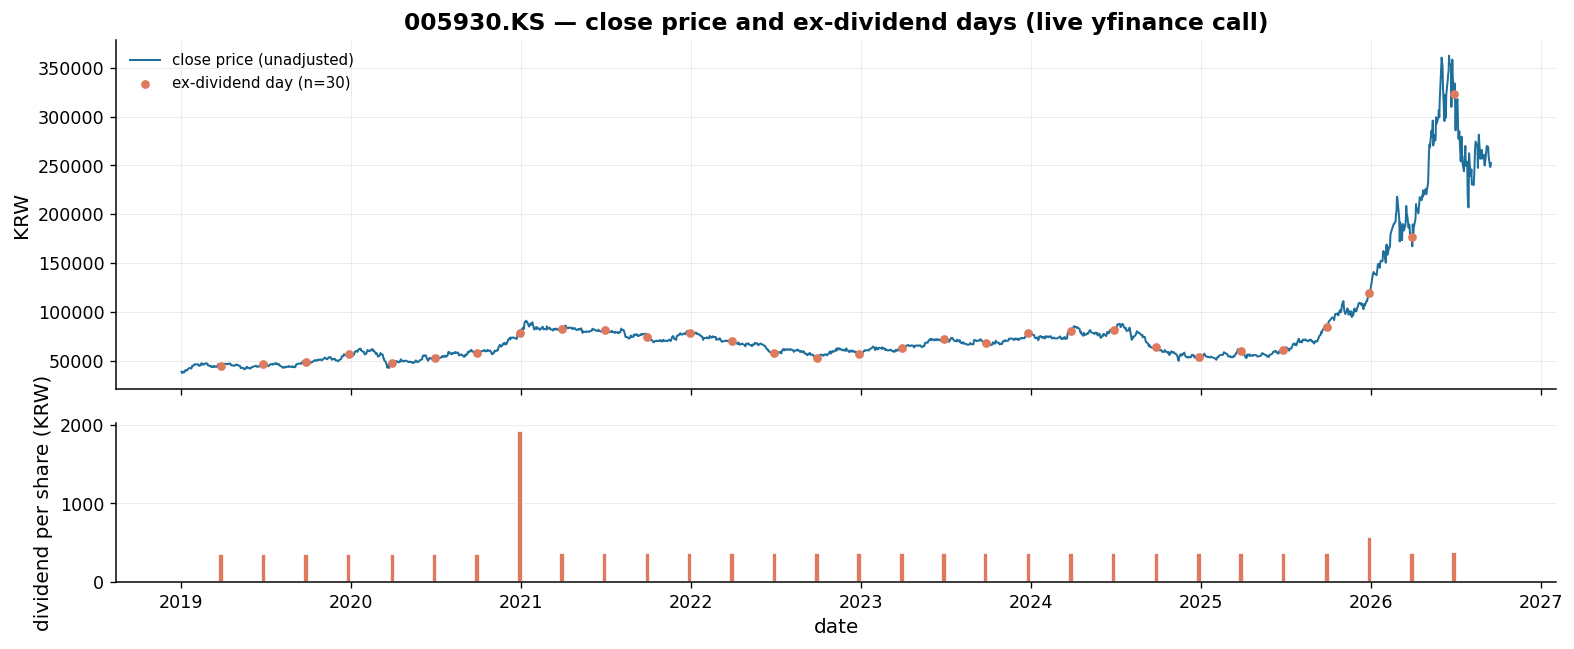

saved -> yfinance_dividend_check.png


In [7]:
p = t.history(start="2019-01-01", auto_adjust=False, actions=True)
e = p[p["Dividends"] > 0]
fig, ax = plt.subplots(2, 1, figsize=(13.333, 5.6), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
ax[0].plot(p.index, p["Close"], color="#1f6f9c", lw=1.2, label="close price (unadjusted)")
ax[0].scatter(e.index, e["Close"], s=18, color="#e07a5f", zorder=5, label=f"ex-dividend day (n={len(e)})")
ax[0].set_ylabel("KRW"); ax[0].set_title(f"{TK} — close price and ex-dividend days (live yfinance call)")
ax[0].legend(fontsize=9); ax[0].grid(color="#dddddd", lw=.5, alpha=.6)
ax[1].bar(e.index, e["Dividends"], width=12, color="#e07a5f", edgecolor="white")
ax[1].set_ylabel("dividend per share (KRW)"); ax[1].set_xlabel("date")
ax[1].grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("yfinance_dividend_check")); plt.show()
print("saved ->", fm.image("yfinance_dividend_check").name)

## 정리

- `yfinance` 응답에는 **`Dividends` 열이 실제로 있고**, 배당락일마다 주당 배당금이 들어 있다 (19-1).
- MC 가 쓰는 δ 는 이 표의 **배당금 ÷ 전일 종가** 그대로다 (19-2).
- 가격지수는 배당이 0 이라 **추종 ETF 분배금**으로 대체했고, DAX 는 총수익지수라 0 을 그대로 썼다 (19-3).
- 저장된 캐시는 API 값과 같다 (19-4).

**한계**: 지수를 ETF 분배금으로 대신하므로 분배일이 구성종목 배당락일보다 1~3개월 늦을 수 있다
(노트북 16 에서 잰 시점 효과는 상품당 7.5원 수준). yfinance 는 비공식 API 라 값이 바뀌거나 호출이 막힐 수 있어,
MC 는 항상 저장된 캐시를 읽는다.